We want to compare the timescales of the rates involved in these two sequences:

$${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(,e^+\nu){}^{13}\mathrm{C}(p,\gamma){}^{14}\mathrm{N}$$

$${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(,e^+\nu){}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$$

We can compute these as:

$$\tau_x = \frac{Y_x}{|(dY/dt)_x|}$$

and we can use `Rate.eval_full_rate` to get the $dY/dt$ for each rate.

In [1]:
import pynucastro as pyna

In [2]:
rl = pyna.ReacLibLibrary()

Get the rates.

In [3]:
rc12pg = rl.get_rate_by_name("c12(p,g)n13")
rn13beta = rl.get_rate_by_name("n13(,)c13")
rc13pg = rl.get_rate_by_name("c13(p,g)n14")

rn14pg = rl.get_rate_by_name("n14(p,g)o15")
ro15beta = rl.get_rate_by_name("o15(,)n15")
rn15pa = rl.get_rate_by_name("n15(p,a)c12")

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Let's create a network with these just to see the density dependence in the $dY/dt$ terms.

In [5]:
net = pyna.PythonNetwork(rates=[rc12pg, rn13beta, rc13pg,
                                rn14pg, ro15beta, rn15pa])

In [6]:
print(net.full_ydot_string(pyna.Nucleus("c12")))
print(net.full_ydot_string(pyna.Nucleus("n13")))
print(net.full_ydot_string(pyna.Nucleus("c13")))

dYdt[jc12] = (
      -rho*Y[jp]*Y[jc12]*rate_eval.p_C12_to_N13_reaclib  +
      +rho*Y[jp]*Y[jn15]*rate_eval.p_N15_to_He4_C12_reaclib
   )


dYdt[jn13] = (
      +rho*Y[jp]*Y[jc12]*rate_eval.p_C12_to_N13_reaclib  +
      -Y[jn13]*rate_eval.N13_to_C13_reaclib
   )


dYdt[jc13] = (
      +Y[jn13]*rate_eval.N13_to_C13_reaclib  +
      -rho*Y[jp]*Y[jc13]*rate_eval.p_C13_to_N14_reaclib
   )




In [7]:
net.unique_nuclei

[p, He4, C12, C13, N13, N14, N15, O15]

Evaluate at a range of temperatures and compute the timescales.  We'll use a solar composition.

In [8]:
rho = 100
comp = pyna.Composition(net.unique_nuclei, init="solar")
Ys = comp.get_molar()

In [9]:
Ts = np.logspace(7, 8.5, 100)

In [10]:
from pynucastro import Nucleus, ThermoState

In [11]:
tau_c12pg = [Ys[Nucleus("c12")] /
             rc12pg.eval_full_rate(ThermoState(rho=rho, T=T, comp=comp))
             for T in Ts]
tau_n13beta = [Ys[Nucleus("n13")] /
               rn13beta.eval_full_rate(ThermoState(rho=rho, T=T, comp=comp))
               for T in Ts]
tau_c13pg = [Ys[Nucleus("c13")] /
             rc13pg.eval_full_rate(ThermoState(rho=rho, T=T, comp=comp))
             for T in Ts]

tau_n14pg = [Ys[Nucleus("n14")] /
             rn14pg.eval_full_rate(ThermoState(rho=rho, T=T, comp=comp))
             for T in Ts]
tau_o15beta = [Ys[Nucleus("o15")] /
               ro15beta.eval_full_rate(ThermoState(rho=rho, T=T, comp=comp))
               for T in Ts]
tau_n15pa = [Ys[Nucleus("n15")] /
             rn15pa.eval_full_rate(ThermoState(rho=rho, T=T, comp=comp))
             for T in Ts]

Plot the ${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(,e^+\nu){}^{13}\mathrm{C}(p,\gamma){}^{14}\mathrm{N}$ timescales.

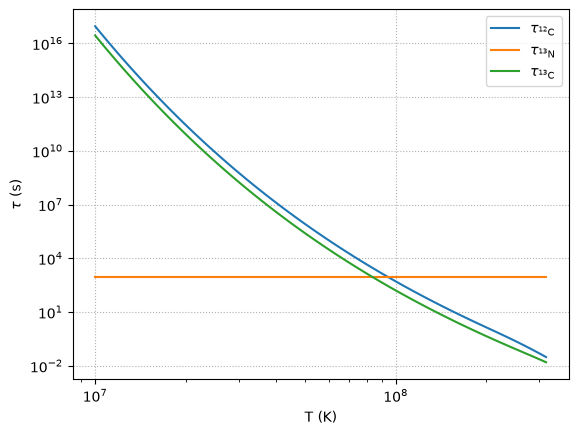

In [12]:
fig, ax = plt.subplots()
ax.loglog(Ts, tau_c12pg, label=r"$\tau_{{}^{12}{\rm C}}$")
ax.loglog(Ts, tau_n13beta, label=r"$\tau_{{}^{13}{\rm N}}$")
ax.loglog(Ts, tau_c13pg, label=r"$\tau_{{}^{13}{\rm C}}$")

ax.set_xlabel("T (K)")
ax.set_ylabel(r"$\tau$ (s)")

ax.legend()
ax.grid(ls=":")

Plot the ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(,e^+\nu){}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$ timescales.

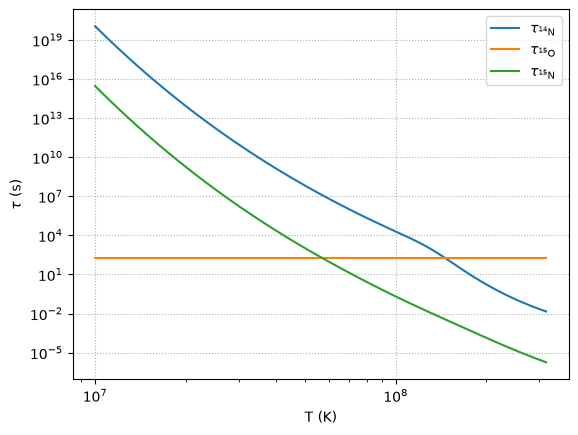

In [13]:
fig, ax = plt.subplots()
ax.loglog(Ts, tau_n14pg, label=r"$\tau_{{}^{14}{\rm N}}$")
ax.loglog(Ts, tau_o15beta, label=r"$\tau_{{}^{15}{\rm O}}$")
ax.loglog(Ts, tau_n15pa, label=r"$\tau_{{}^{15}{\rm N}}$")

ax.set_xlabel("T (K)")
ax.set_ylabel(r"$\tau$ (s)")

ax.legend()
ax.grid(ls=":")


In [15]:
fig.savefig("n14_timescales.pdf", bbox_inches="tight")